In [1]:
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Dataset Loading

In [2]:
# โหลดไฟล์ .npy
images = np.load("../../data/processed_data/char_level_2/images.npy")
labels = np.load("../../data/processed_data/char_level_2/labels.npy")

# ตรวจสอบข้อมูล
print(f"Shape of images: {images.shape}")
print(f"Shape of labels: {labels.shape}")


Shape of images: (3899, 32, 32)
Shape of labels: (3899,)


In [3]:
X = images
y = labels

# ดู min max
print("min max:",np.min(X), np.max(X))

# หา missing value
print("missing value:",np.isnan(X).sum())

# คลาส
print("class:", np.unique(y))

min max: 0 255
missing value: 0
class: [ 0  1  2  3  4  5  6  7  8  9 10 11]


# Visualization

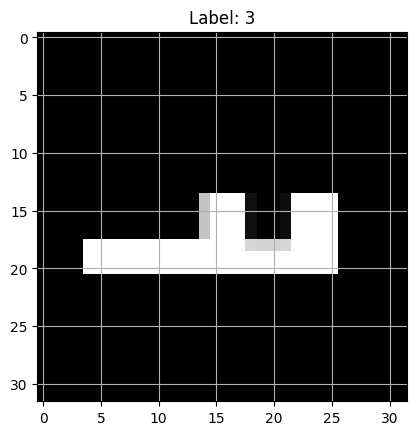

In [4]:
# แสดงภาพเดี่ยว(Single Image)
# แสดงภาพตัวอย่างแรก
plt.imshow(images[0], cmap="gray")
plt.title(f"Label: {labels[0]}")
plt.axis("on")  # ซ่อนแกน
plt.grid()
plt.show()


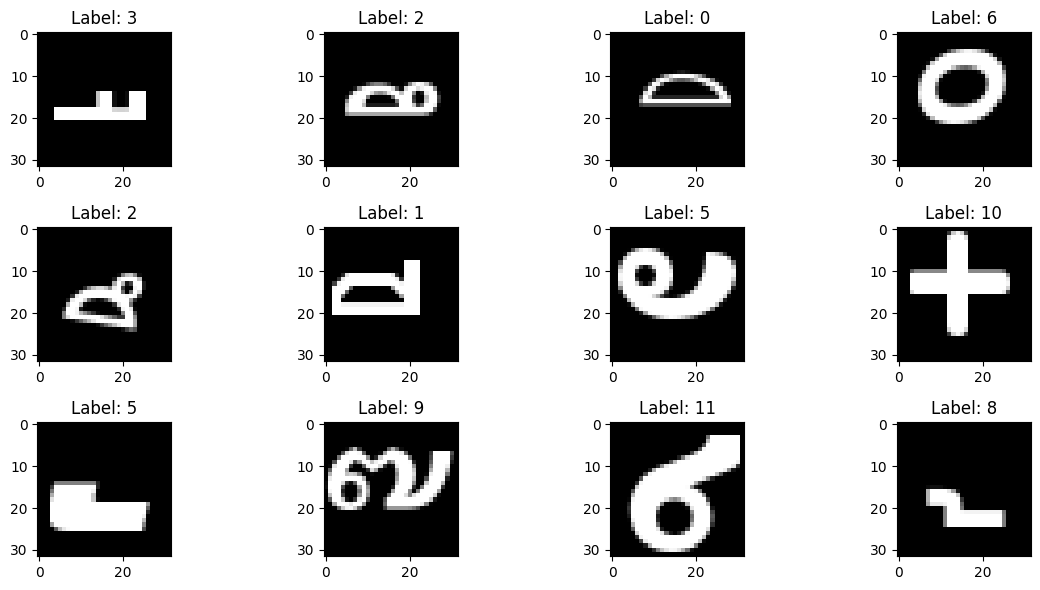

In [6]:
# ตั้งค่าจำนวนภาพที่ต้องการแสดง
num_images = 12  # จำนวนภาพทั้งหมดที่ต้องการแสดง
num_cols = 4     # จำนวนคอลัมน์
num_rows = num_images // num_cols

# สร้างกริดภาพ
fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    if i < num_images:
        ax.imshow(images[i], cmap="gray")
        ax.set_title(f"Label: {labels[i]}")
        ax.axis("on")

plt.tight_layout()
plt.show()

### ตรวจสอบความสมดุลของคลาส (Class Distribution)

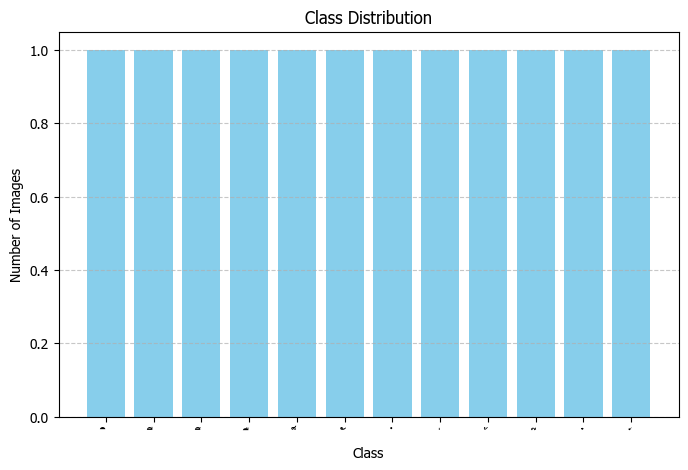

In [7]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ตั้งค่า font ให้รองรับภาษาไทย (ตรวจสอบว่า font ดังกล่าวติดตั้งในระบบแล้ว)
plt.rcParams['font.family'] = ['Tahoma']  # หรือใช้ ['Sarabun'] หากมี font นี้
plt.rcParams['axes.unicode_minus'] = False  # แก้ปัญหาเครื่องหมายลบไม่แสดง

from collections import Counter

labels = [
     'ิ', 'ี', 'ึ', 'ื', '็', 'ั', 'ํ', '่', '้', '๊', '๋', '์'
]

# นับจำนวนคลาส
class_counts = Counter(labels)

# แสดงกราฟแท่ง (Bar Plot)
plt.figure(figsize=(8, 5))  # ปรับขนาดกราฟ
plt.bar(class_counts.keys(), class_counts.values(), color="skyblue")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

## Train-test Split

In [8]:
from sklearn.model_selection import train_test_split

# 1. แบ่งข้อมูลทั้งหมดออกเป็น Training (70%) กับ Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# 2. จากข้อมูล Temp 30% แบ่งออกเป็น Validation และ Test เท่ากัน (แต่ละ 15% ของข้อมูลทั้งหมด)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# ตรวจสอบสัดส่วนข้อมูล
print("Training set:", len(X_train))
print("Validation set:", len(X_val))
print("Test set:", len(X_test))

Training set: 2729
Validation set: 585
Test set: 585


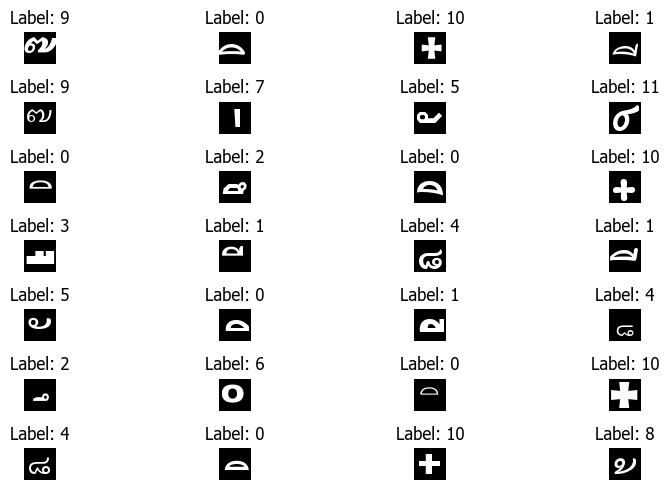

In [9]:
# ตั้งค่าจำนวนภาพที่ต้องการแสดง
num_images = 30  # จำนวนภาพทั้งหมดที่ต้องการแสดง
num_cols = 4     # จำนวนคอลัมน์
num_rows = num_images // num_cols

# สร้างกริดภาพ
fig, axes = plt.subplots(num_rows, num_cols, figsize=(9, 5))

for i, ax in enumerate(axes.flat):
    if i < num_images:
        ax.imshow(X_train[i], cmap="gray")
        ax.set_title(f"Label: {y_train[i]}")
        ax.axis("off")

plt.tight_layout()
plt.show()

In [10]:
print(X_train.shape)
print(X_test.shape)

(2729, 32, 32)
(585, 32, 32)


## Prepare Dataset (Re-shape the Structure)

In [11]:
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)
X_val = np.expand_dims(X_val, -1)

In [12]:
# Normalize
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
X_val = X_val.astype('float32') / 255.0

In [13]:
# Normalize Check
np.min(X_train), np.max(X_train)

(0.0, 1.0)

In [14]:
# Dimension Check
X_train.shape

(2729, 32, 32, 1)

In [15]:
print('Train: X={}, y={}'.format(X_train.shape, y_train.shape))
print('Test: X={}, y={}'.format(X_test.shape, y_test.shape))

Train: X=(2729, 32, 32, 1), y=(2729,)
Test: X=(585, 32, 32, 1), y=(585,)


# Create Model

In [16]:
num_classes = len(np.unique(y_train))
in_shape = X_train.shape[1:]

print("num classes:",num_classes)
print("input shape:",in_shape)

num classes: 12
input shape: (32, 32, 1)


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# สร้างโมเดล CNN
model = Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=in_shape),  # 32 filters, 3x3 kernel
    #BatchNormalization(),
    MaxPooling2D((2, 2)),  # ลดขนาดภาพลงครึ่งหนึ่ง

    # Block 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),  # 64 filters
    #BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Block 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),  # 128 filters
    #BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Flatten และ Fully Connected Layers
    Flatten(),
    Dense(256, activation='relu'),  # Fully Connected Layer
    Dropout(0.5),  # ลด Overfitting
    Dense(num_classes, activation='softmax')  # Output Layer สำหรับ 26 คลาส
])

# สรุปโครงสร้างโมเดล
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 16, 16, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 8, 8, 64)         0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 8, 8, 128)         73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 4, 4, 128)        0

In [ ]:
'''
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])
'''

In [18]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [19]:
import time
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# สร้าง object สำหรับ data augmentation ด้วยการกำหนดพารามิเตอร์ที่ต้องการ
datagen = ImageDataGenerator(
    rotation_range=10,         # หมุนภาพสุ่มไม่เกิน 10 องศา
    width_shift_range=0.1,     # เลื่อนภาพในแนวราบไม่เกิน 20%
    height_shift_range=0.1,    # เลื่อนภาพในแนวตั้งไม่เกิน 20%
    shear_range=0.1,           # ปรับมุมของภาพ
    zoom_range=0.1,            # ซูมเข้าออก
    horizontal_flip=False,     # พลิกภาพในแนวนอน (ถ้าจำเป็นให้ตั้งเป็น True)
    fill_mode='nearest'        # วิธีเติมพิกเซลที่หายไปหลังการแปลง
)

start = time.time()
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# เทรนโมเดลโดยใช้ข้อมูลที่ถูกปรับปรุงแบบ Augmentation
datagen.fit(X_train)
history = model.fit(X_train, y_train,
                    batch_size=32,
                    epochs=100,
                    validation_data=(X_val, y_val),
                    callbacks=[early_stopping],
                    verbose=1)

end = time.time()
print("Time Taken: {:.2f} minutes".format((end - start)/60))

Epoch 1/100
86/86 [==============================] - 5s 7ms/step - loss: 1.3348 - accuracy: 0.5354 - val_loss: 0.4022 - val_accuracy: 0.8496
Epoch 2/100
86/86 [==============================] - 0s 5ms/step - loss: 0.3627 - accuracy: 0.8703 - val_loss: 0.1253 - val_accuracy: 0.9641
Epoch 3/100
86/86 [==============================] - 0s 5ms/step - loss: 0.1675 - accuracy: 0.9502 - val_loss: 0.0781 - val_accuracy: 0.9726
Epoch 4/100
86/86 [==============================] - 0s 4ms/step - loss: 0.1148 - accuracy: 0.9604 - val_loss: 0.0562 - val_accuracy: 0.9812
Epoch 5/100
86/86 [==============================] - 0s 5ms/step - loss: 0.0822 - accuracy: 0.9725 - val_loss: 0.0426 - val_accuracy: 0.9880
Epoch 6/100
86/86 [==============================] - 0s 5ms/step - loss: 0.0740 - accuracy: 0.9718 - val_loss: 0.0506 - val_accuracy: 0.9863
Epoch 7/100
86/86 [==============================] - 0s 5ms/step - loss: 0.0547 - accuracy: 0.9798 - val_loss: 0.0340 - val_accuracy: 0.9915
Epoch 8/100
8

In [20]:
#test_loss, test_acc = model.evaluate(X_test, y_test)
#print(f"Test Accuracy: {test_acc * 100:.2f}%")

score = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {score[0] * 100:.3f}%")
print(f"Test Accuracy: {score[1] * 100:.3f}%")

19/19 [==============================] - 0s 9ms/step - loss: 0.0356 - accuracy: 0.9915
Test Loss: 3.558%
Test Accuracy: 99.145%


### รายละเอียดของกราฟ
Loss:

-Train Loss: แสดงว่าโมเดลเรียนรู้ข้อมูล Training ได้ดีแค่ไหน

-Validation Loss: ช่วยบอกว่าโมเดลเรียนรู้ข้อมูลใหม่ (ที่ไม่เคยเห็นมาก่อน) ได้ดีแค่ไหน

-Validation Loss ที่ลดลงต่อเนื่องแสดงว่าโมเดลยังเรียนรู้ได้ดี แต่ถ้าเพิ่มขึ้นอาจบ่งชี้ว่า Overfitting

Accuracy:

-Train Accuracy: ความแม่นยำของโมเดลบนข้อมูล Training

-Validation Accuracy: ความแม่นยำของโมเดลบนข้อมูล Validation

-ค่า Accuracy ที่ใกล้เคียงกันระหว่าง Train และ Validation หมายถึงโมเดลกำลังเรียนรู้ได้ดี


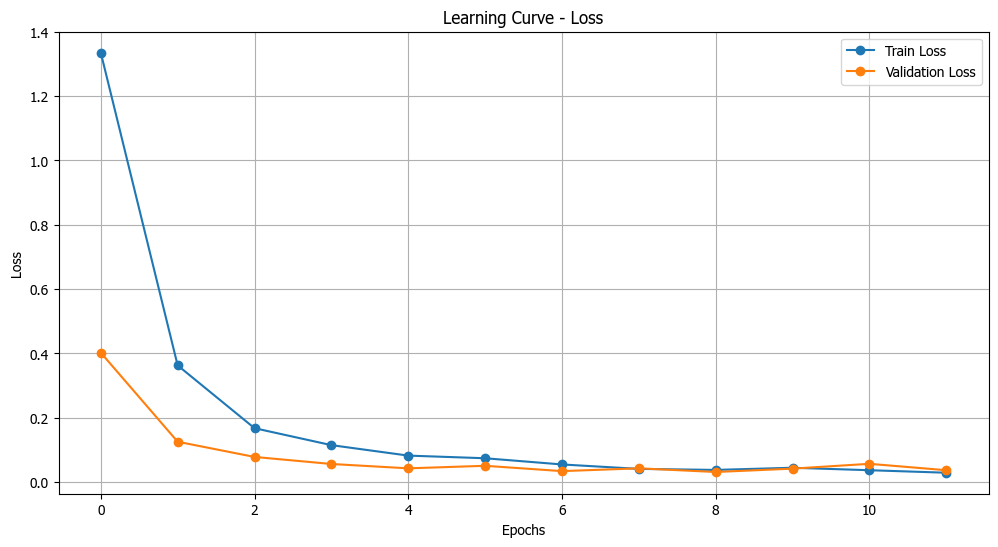

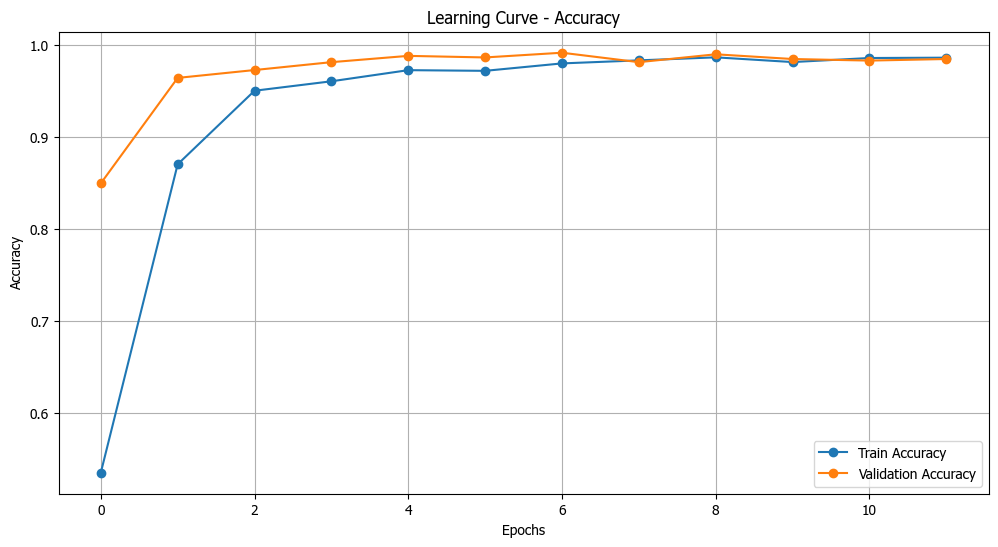

In [21]:
# ดึงข้อมูล Loss และ Accuracy
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# สร้างกราฟ Loss
plt.figure(figsize=(12, 6))
plt.plot(train_loss, label='Train Loss', marker='o')
plt.plot(val_loss, label='Validation Loss', marker='o')
plt.title('Learning Curve - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# สร้างกราฟ Accuracy
plt.figure(figsize=(12, 6))
plt.plot(train_acc, label='Train Accuracy', marker='o')
plt.plot(val_acc, label='Validation Accuracy', marker='o')
plt.title('Learning Curve - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

## Confusion Matrix

19/19 [==============================] - 0s 9ms/step


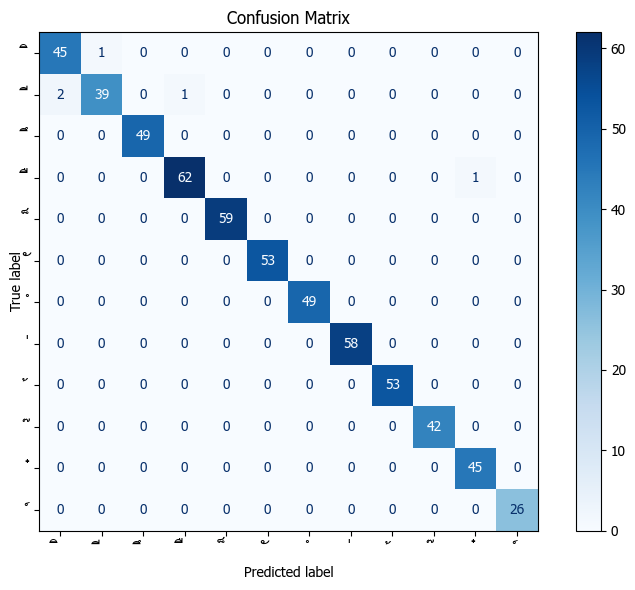

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ตรวจสอบและแปลง y_test ให้เป็น label vector หากอยู่ในรูปแบบ One-Hot
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

# ทำนายผลจากโมเดลบนชุดข้อมูล X_test
y_pred = model.predict(X_test)
# แปลงผลการทำนายให้เป็น label โดยใช้ argmax
y_pred_classes = np.argmax(y_pred, axis=1)

# คำนวณ Confusion Matrix จาก y_true และ y_pred_classes
cm = confusion_matrix(y_true, y_pred_classes)

labels_names = [
     'ิ', 'ี', 'ึ', 'ื', '็', 'ั', 'ํ', '่', '้', '๊', '๋', '์'
]

# สร้างและปรับขนาดกราฟสำหรับ Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_names)
disp.plot(cmap='Blues', ax=ax)

# ปรับขนาด tick labels สำหรับแกน x และ y
for label in ax.get_xticklabels():
    label.set_fontsize(15)
for label in ax.get_yticklabels():
    label.set_fontsize(15)

plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


# Test Model

### ใช้ Metric เพิ่มเติม
Precision, Recall, F1-Score
วัดประสิทธิภาพของโมเดลในแต่ละคลาส:

-Precision: โฟกัสที่ความถูกต้องของการทำนาย Positive

-Recall: โฟกัสที่ความครบถ้วนของการจับ Positive

-F1-Score: สมดุลระหว่าง Precision และ Recall

-Macro Avg: ค่าเฉลี่ยที่ให้ความสำคัญเท่ากันทุกคลาส ไม่สนใจ Support

-Weighted Avg: ค่าเฉลี่ยที่คำนึงถึงขนาดของคลาส เหมาะกับข้อมูลไม่สมดุล

-ใช้ Macro เมื่อทุกคลาสสำคัญเท่ากัน และ Weighted เมื่อต้องการสะท้อนความสำคัญของข้อมูลทั้งชุด

In [26]:
from sklearn.metrics import classification_report

letter_labels = [ 'ิ', 'ี', 'ึ', 'ื', '็', 'ั', 'ํ', '่', '้', '๊', '๋', '์']  # ปรับตามความเหมาะสม
# รายงานผลการทำนาย
print(classification_report(y_true, y_pred_classes, target_names=letter_labels))  # ปรับ range ตามจำนวนคลาส

              precision    recall  f1-score   support

           ิ       0.96      0.98      0.97        46
           ี       0.97      0.93      0.95        42
           ึ       1.00      1.00      1.00        49
           ื       0.98      0.98      0.98        63
           ็       1.00      1.00      1.00        59
           ั       1.00      1.00      1.00        53
           ํ       1.00      1.00      1.00        49
           ่       1.00      1.00      1.00        58
           ้       1.00      1.00      1.00        53
           ๊       1.00      1.00      1.00        42
           ๋       0.98      1.00      0.99        45
           ์       1.00      1.00      1.00        26

    accuracy                           0.99       585
   macro avg       0.99      0.99      0.99       585
weighted avg       0.99      0.99      0.99       585



### การวิเคราะห์ตัวอย่างที่โมเดลทำนายผิด
แสดงภาพที่โมเดลทำนายผิด

In [29]:
import numpy as np

# หา Index ของภาพที่ทำนายผิด
incorrect_indices = np.where(y_true != y_pred_classes)[0]

# แสดงภาพตัวอย่างที่โมเดลทำนายผิด
for i in incorrect_indices[:10]:  # แสดง 10 ตัวอย่างแรก
    plt.imshow(X_test[i].squeeze(), cmap='gray')
    plt.title(f"True: {y_true[i]}, Predicted: {letter_class[y_pred_classes[i]]}")
    plt.axis("off")
    plt.show()


## Save Model

In [27]:
model.save('../../models/char_level_2_model.h5')